**1.Project Introduction**

**Project title**

**Toxic Comment Classification Using Machine Learning**

**1.1 Introduction**

Online discussion platforms generate large volumes of user-generated content, making manual identification of harmful or toxic comments difficult to perform consistently at scale. Automated toxicity detection can support content moderation by identifying potentially harmful comments for further review.

This project investigates the use of Natural Language Processing (NLP) and machine learning to classify online comments as toxic or non-toxic using the Jigsaw Toxic Comment Classification dataset. Although the original dataset contains multiple toxicity categories, this analysis focuses exclusively on the toxic target to establish a clear and consistent binary classification problem.

**1.2 Objective**

The objective of this project is to develop and systematically evaluate machine learning approaches for toxic-comment classification. The analysis compares classical NLP-based models with a deep-learning approach and uses validation performance to identify the most suitable model.

The modelling workflow follows a structured training → validation → tuning → final testing process. The test set is retained until the final evaluation to provide an unbiased assessment of the selected model.

**1.3 Evaluate Approach**

Because the target variable is imbalanced, F1-score is used as the primary model-selection metric, supported by precision, recall, and ROC-AUC. This allows the analysis to consider both types of classification error rather than relying on accuracy alone.

**1.4 Research Question**

Which machine learning approach provides the most effective classification of toxic and non-toxic comments based on validation performance?

**2.Dataset Understanding**

**2.1 Dataset Description**

The dataset used in this project is the Jigsaw Toxic Comment Classification dataset. It contains user-generated online comments labelled according to different types of toxic behaviour.

The original dataset contains approximately 159,571 comments and six toxicity-related labels. For this project, the analysis focuses specifically on the `toxic` label to formulate a binary classification problem.

The target variable is:

- `toxic = 1`: Toxic comment
- `toxic = 0`: Non-toxic comment

**2.2 Import Libraries**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping


**2.3 Load Dataset**

In [59]:
df = pd.read_csv("/content/train.csv (2).zip")
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [60]:
df.shape

(159571, 8)

In [61]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [62]:
TEXT_COLUMN = "comment_text"
TARGET_COLUMN = "toxic"

**3.Data Quality Assessment**

**3.1 Basic Information**


The dataset structure was reviewed to understand the available variables, data types and overall volume of observations. The comment text serves as the primary input feature, while `toxic` is used as the classification target.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [64]:
df.describe(include="all")

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571,159571,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
unique,159571,159571,NaN,NaN,NaN,NaN,NaN,NaN
top,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,NaN,NaN,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


**3.2 Missing Values**

In [65]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


Missing values were assessed to determine whether incomplete observations could affect the modelling pipeline. The results were reviewed before proceeding with text preprocessing and model development.

**3.3 Duplicate Comments**

In [66]:
df["comment_text"].duplicated().sum()

np.int64(0)

Duplicate comments were examined to identify repeated observations that could introduce redundancy or influence model evaluation.

**3.4 Duplicate Rows**

In [67]:
df.duplicated().sum()

np.int64(0)

The dataset was checked for completely duplicated records to ensure that repeated observations were not unintentionally retained.

**3.5 Empty comments**

In [68]:
(df["comment_text"].str.strip() == "").sum()

np.int64(0)

Empty or whitespace-only comments were identified because they provide no meaningful textual information for NLP-based classification.

**3.6 Target validity**

In [69]:
df["toxic"].value_counts()

,count
toxic,
0,144277
1,15294


The target variable was checked to confirm that the classification problem contains only the expected binary classes, 0 and 1. This ensures consistency between the target definition and the subsequent modelling process.

In [70]:
df["toxic"].value_counts(normalize=True) * 100

,proportion
toxic,
0,90.415552
1,9.584448


**3.7 Data Cleaning**

In [71]:
df = df.drop_duplicates()

In [72]:
df = df.dropna(subset=["comment_text", "toxic"])

In [ ]:

df = df[df["comment_text"].str.strip() != ""]

In [73]:
df = df[["comment_text", "toxic"]].copy()

In [74]:
print("Final dataset shape:", df.shape)

Final dataset shape: (159571, 2)


**Data Quality Summary**

The dataset was checked for missing values, duplicate records and duplicate comments. Records without a comment or target value were removed because they cannot be used reliably for supervised text classification. Duplicate records were also removed to reduce the risk of repeated observations influencing the model.

**Target Definition**

In [75]:
df["target"] = df["toxic"].astype(int)

**4.Exploratory Data Analysis**

**4.1 Class Distribution**

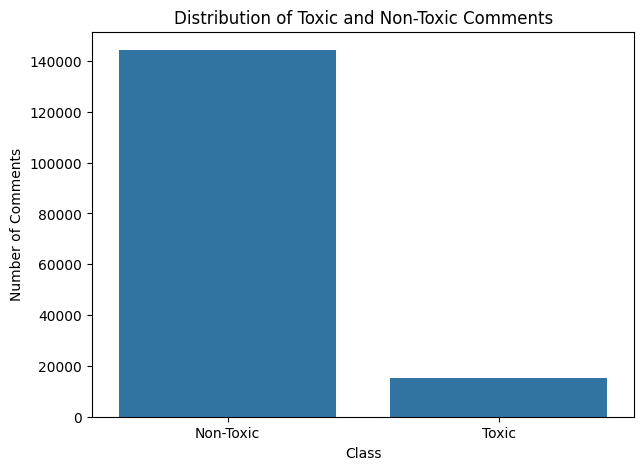

In [78]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="target")

plt.title("Distribution of Toxic and Non-Toxic Comments")
plt.xlabel("Class")
plt.ylabel("Number of Comments")
plt.xticks([0, 1], ["Non-Toxic", "Toxic"])

plt.show()

In [79]:
target_percentage = df["toxic"].value_counts(normalize=True) * 100
target_percentage

,proportion
toxic,
0,90.415552
1,9.584448


Interpretation

The target distribution is substantially imbalanced, with non-toxic comments representing approximately 90.42% of observations and toxic comments approximately 9.58%.

This imbalance is important for model evaluation because a model could achieve high accuracy by favouring the majority class while performing poorly on toxic comments. Therefore, precision, recall and F1-score are considered alongside accuracy, with F1-score used as the primary model-selection metric.

**4.2 Comment Length**

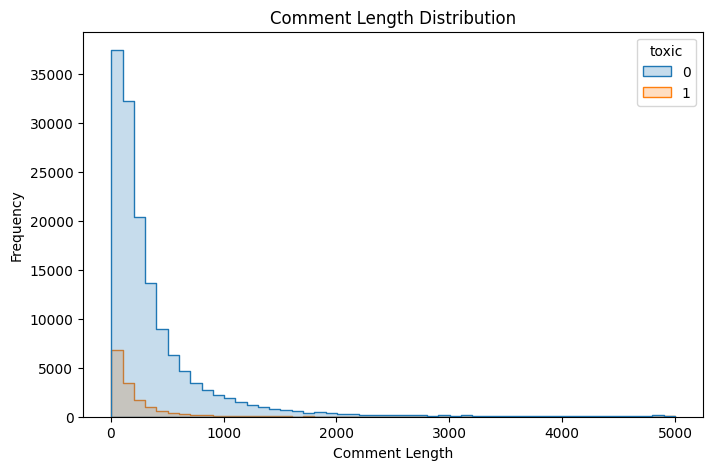

In [82]:
df["comment_length"] = df["comment_text"].str.len()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="comment_length",
    hue="toxic",
    bins=50,
    element="step"
)

plt.title("Comment Length Distribution")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.show()

Interpretation

Comment length was analysed to understand the distribution of textual content across the dataset and to identify potential differences between toxic and non-toxic comments.

The analysis provides an initial view of the complexity of the text that the classification models need to process. However, comment length alone is not sufficient to distinguish toxicity, which motivates the use of text-based feature representations in the modelling stage.

**4.3 Word Count**

In [83]:
df["word_count"] = df["comment_text"].str.split().str.len()

df.groupby("toxic")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
toxic,,,,,,,,
0,144277.0,68.967874,98.279574,1.0,18.0,38.0,78.0,1250.0
1,15294.0,51.289787,106.475663,2.0,11.0,22.0,48.0,1411.0


(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

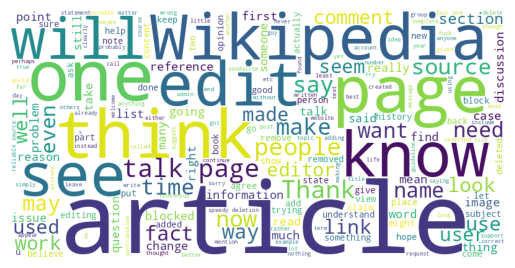

In [85]:
text = " ".join(df['comment_text'].astype(str))

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')

Interpretation

Word count provides an additional measure of textual complexity. Examining the distribution across the target classes helps assess whether differences in the amount of textual information may influence classification.

These descriptive characteristics are used to understand the dataset rather than as standalone predictors of toxicity.

**Word count by class**

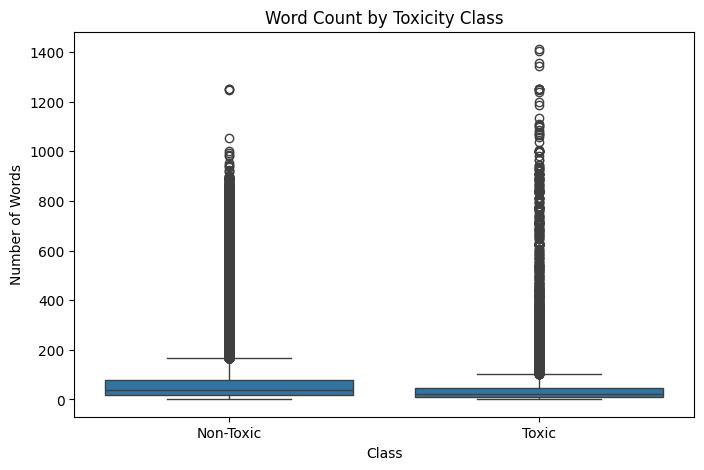

In [87]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="target",
    y="word_count"
)

plt.title("Word Count by Toxicity Class")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.xticks(
    [0, 1],
    ["Non-Toxic", "Toxic"]
)

plt.show()

**EDA Findings**

The exploratory analysis identified two important characteristics of the dataset. First, the target variable is strongly imbalanced, with toxic comments representing a minority of observations. Second, comments vary considerably in their textual length and word count.

The class imbalance is particularly relevant to model evaluation and motivates the use of F1-score, precision and recall rather than relying on accuracy alone. The observed variation in text characteristics also supports the use of NLP-based feature extraction and sequence modelling in the subsequent analysis.

**5.Text Preprocessing**

The comment text was cleaned and standardised before feature extraction. This step prepares the raw user-generated text for the two modelling approaches used in the analysis: TF-IDF-based classical machine learning and sequence-based LSTM modelling.

The same cleaned comment text is retained as the common input source, while each modelling approach applies its own feature representation.

In [88]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["comment_text"].apply(clean_text)

df[["comment_text", "clean_text"]].head()

,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d'aww! he matches this background colour i'm s...
2,"Hey man, I'm really not trying to edit war. It...","hey man, i'm really not trying to edit war. it..."
3,"""\nMore\nI can't make any real suggestions on ...",""" more i can't make any real suggestions on im..."
4,"You, sir, are my hero. Any chance you remember...","you, sir, are my hero. any chance you remember..."


**6.Train / Validation / Test Split**

The dataset was divided into training, validation and test subsets using a 70%, 15% and 15% split respectively, with stratification applied to preserve the distribution of the toxic and non-toxic classes.

The training set is used to fit the models. The validation set is used to compare candidate models and support hyperparameter tuning, while the test set is held back for the final evaluation of the selected model.

This structure ensures that the final test performance is assessed on data that was not used during model comparison or tuning.

In [89]:
X = df["clean_text"]
y = df["toxic"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Training: 111699
Validation: 23936
Test: 23936


The dataset was divided into training, validation and test sets using stratified sampling. The training set is used to train models, the validation set is used for model comparison and hyperparameter selection, and the test set remains untouched until the final evaluation.

**7.TF-IDF Feature Extraction**

In [90]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

In [91]:
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)

Train: (111699, 50000)
Validation: (23936, 50000)
Test: (23936, 50000)


The cleaned comments were transformed into TF-IDF features for the classical machine learning models. Both unigrams and bigrams were included to capture individual terms as well as short word combinations.

The feature representation was limited to the most relevant terms to maintain a practical feature space while retaining useful information for classification.

**8.Baseline Model**

In [92]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train_tfidf, y_train)

baseline_pred = baseline.predict(X_val_tfidf)

baseline_f1 = f1_score(y_val, baseline_pred)

print("Baseline F1:", baseline_f1)

Baseline F1: 0.0


In [93]:
print("Precision:",
      precision_score(y_val, baseline_pred, zero_division=0))

print("Recall:",
      recall_score(y_val, baseline_pred, zero_division=0))

print("F1:",
      f1_score(y_val, baseline_pred, zero_division=0))

Precision: 0.0
Recall: 0.0
F1: 0.0


The majority-class baseline provides a reference point for assessing whether the machine learning models identify toxic comments more effectively than simply predicting the dominant class.

Its poor minority-class performance demonstrates why the modelling task cannot be evaluated using accuracy alone and reinforces the need to consider precision, recall and F1-score.

**9.Model 1 - Logistic Regression**

Logistic Regression was selected as a baseline supervised learning model for the TF-IDF features.

Its performance provides a benchmark for a relatively simple and computationally efficient classification approach. The model is evaluated using the same validation metrics as the other candidate models to ensure a consistent comparison.

In [94]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

**Validation**



In [95]:
lr_val_pred = lr_model.predict(X_val_tfidf)

lr_val_prob = lr_model.predict_proba(
    X_val_tfidf
)[:, 1]

**Evaluate:**

In [96]:
lr_results = {
    "Model": "Logistic Regression",
    "Precision": precision_score(y_val, lr_val_pred),
    "Recall": recall_score(y_val, lr_val_pred),
    "F1": f1_score(y_val, lr_val_pred),
    "ROC-AUC": roc_auc_score(y_val, lr_val_prob)
}

lr_results

{'Model': 'Logistic Regression',
 'Precision': 0.6363343013875443,
 'Recall': 0.8596338273757629,
 'F1': 0.7313183756721676,
 'ROC-AUC': np.float64(0.9706368582288613)}



Logistic Regression achieves a validation precision of 0.636 and recall of 0.860, resulting in an F1-score of 0.731.

The relatively high recall indicates that the model identifies a large proportion of toxic comments, while the lower precision indicates that a considerable number of non-toxic comments are also classified as toxic.

This provides a useful baseline for comparing the trade-off between identifying toxic content and limiting false-positive classifications.

**10.MODEL 2 — Linear Support Vector Machine**

Linear SVM was evaluated because margin-based linear classifiers are well suited to high-dimensional text representations such as TF-IDF.

Using the same feature representation as Logistic Regression allows the comparison to focus on differences in the learning approach rather than differences in the input features.

In [97]:
svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC(class_weight='balanced', random_state=42)

**Validation**

In [98]:
svm_val_pred = svm_model.predict(
    X_val_tfidf
)

In [99]:
svm_results = {
    "Model": "Linear SVM",
    "Precision": precision_score(y_val, svm_val_pred),
    "Recall": recall_score(y_val, svm_val_pred),
    "F1": f1_score(y_val, svm_val_pred)
}

svm_results

{'Model': 'Linear SVM',
 'Precision': 0.7198292588280947,
 'Recall': 0.8086312118570184,
 'F1': 0.7616505850954629}


Linear SVM achieves a validation precision of 0.720 and recall of 0.809, producing an F1-score of 0.762.

Compared with Logistic Regression, the SVM provides a stronger balance between precision and recall. Precision increases while recall decreases moderately, resulting in an improvement in F1-score from 0.731 to 0.762.

This makes Linear SVM a stronger classical machine learning candidate based on the validation results.

**11.MODEL 3 — LSTM**

An LSTM-based neural network was developed as a deep-learning alternative to the TF-IDF-based models.

Unlike the classical models, the LSTM processes the comments as sequences of tokens, allowing the model to learn patterns related to the ordering of words.

The model is trained using the training set and monitored against the validation set. Early stopping is used to limit unnecessary training when validation performance stops improving.

**11.1 Tokenization**

In [100]:
MAX_WORDS = 50000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

The text comments were converted into numerical sequences using a vocabulary limit of 50,000 words. This transformation makes the textual data suitable for processing by the LSTM model.

**vocabulary**

In [101]:
print(
    "Vocabulary size:",
    len(tokenizer.word_index)
)

Vocabulary size: 160906


**Convert text to sequences**

In [102]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

**11.2 Analyze sequence lengths**

In [103]:
sequence_lengths = [
    len(seq)
    for seq in X_train_seq
]

pd.Series(sequence_lengths).describe()

,0
count,111699.000000
mean,67.698269
std,100.228969
min,0.000000
25%,17.000000
50%,36.000000
75%,75.500000
max,1403.000000


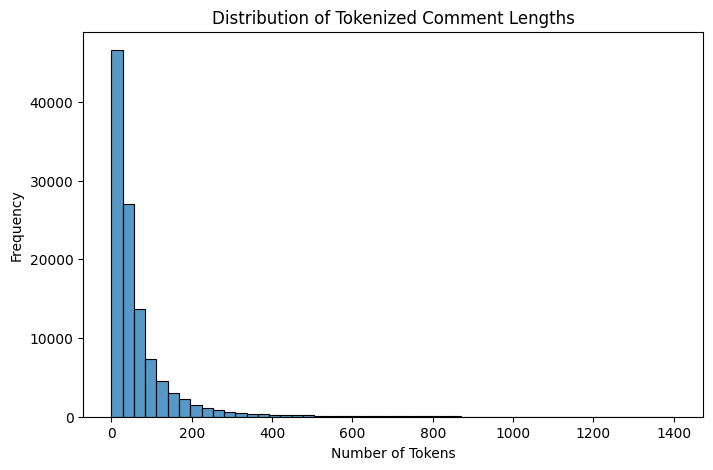

In [104]:
plt.figure(figsize=(8,5))

sns.histplot(
    sequence_lengths,
    bins=50
)

plt.title("Distribution of Tokenized Comment Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.show()

The distribution of tokenized comment lengths shows that most comments contain a relatively small number of tokens, while a smaller number of comments are considerably longer. The distribution is strongly right-skewed, indicating the presence of a long tail of lengthy comments. This variation in sequence length is important for the LSTM model because the input sequences need to be standardized to a common length before training.

In [142]:
print(
    "95th percentile:",
    np.percentile(sequence_lengths, 95)
)

print(
    "99th percentile:",
    np.percentile(sequence_lengths, 99)
)

95th percentile: 231.0
99th percentile: 572.0


The tokenized comments have a highly right-skewed length distribution. The 95th percentile is 231 tokens, while the 99th percentile is 572 tokens. Based on this distribution, a maximum sequence length of 200 tokens was selected to balance information retention with computational efficiency.

In [106]:
MAX_LEN = 200

**11.3 Padding**

In [143]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [144]:
print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

(111699, 200)
(23936, 200)
(23936, 200)


All sequences were padded or truncated to 200 tokens using post-padding and post-truncation. This produced consistent input dimensions of (111,699, 200) for training and (23,936, 200) for both validation and testing

**11.4 Build LSTM**

In [109]:
VOCAB_SIZE = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)

lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    ),

    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [110]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

The LSTM architecture uses an embedding layer with 128 dimensions, a 64-unit LSTM layer with dropout, followed by a 32-unit dense layer and a sigmoid output layer. This architecture is designed to learn sequential patterns in comments while using dropout to reduce overfitting.

**11.5 Early Stopping**

In [111]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Early stopping monitored validation loss with a patience of three epochs and restored the best model weights. This helps prevent unnecessary training once validation performance stops improving.

**11.6 Train LSTM**

In [112]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=5,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 622s 354ms/step - accuracy: 0.9044 - loss: 0.3234 - precision: 0.6857 - recall: 0.0045 - val_accuracy: 0.9050 - val_loss: 0.3115 - val_precision: 0.9524 - val_recall: 0.0087
Epoch 2/5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 627s 357ms/step - accuracy: 0.9055 - loss: 0.3151 - precision: 0.8585 - recall: 0.0164 - val_accuracy: 0.9057 - val_loss: 0.3114 - val_precision: 0.9512 - val_recall: 0.0170
Epoch 3/5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 639s 366ms/step - accuracy: 0.9102 - loss: 0.2613 - precision: 0.6917 - recall: 0.1144 - val_accuracy: 0.9484 - val_loss: 0.1415 - val_precision: 0.7313 - val_recall: 0.7297
Epoch 4/5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 620s 355ms/step - accuracy: 0.9606 - loss: 0.1144 - precision: 0.8479 - recall: 0.7176 - val_accuracy: 0.9622 - val_loss: 0.1047 - val_precision: 0.8468 - val_recall: 0.7398
Epoch 5/5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 640s 365ms/step - accuracy: 0.9730 - loss: 0.0758 - precision: 0.8845 - recall: 0.8266 - val_accura

The LSTM showed substantial learning during training. Validation accuracy increased from 90.50% in Epoch 1 to 96.28% in Epoch 5, while training accuracy increased to 97.30%. Validation recall also improved considerably from 0.0087 to 0.7502, indicating that the model became increasingly effective at identifying the positive class. The relatively small difference between the final training accuracy (97.30%) and validation accuracy (96.28%) suggests that the model generalised well, although the higher training accuracy indicates a modest training–validation gap.

**11.7 LSTM Training Visualization**

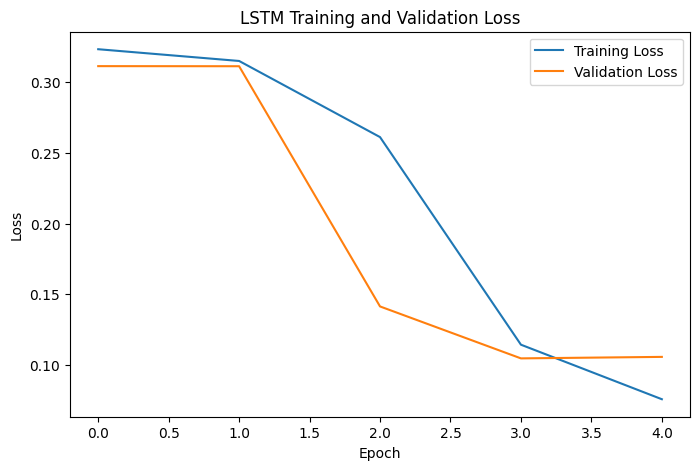

In [145]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Training Behaviour

The training and validation loss curves indicate effective learning by the LSTM model. Training loss decreased consistently across the five epochs, from approximately 0.32 to 0.08. Validation loss also decreased substantially, reaching approximately 0.10 by the fourth epoch, before remaining almost stable in the final epoch. The decreasing training loss together with the stabilisation of validation loss suggests that the model was learning useful patterns while further training provided limited additional validation improvement.

**Accuracy**

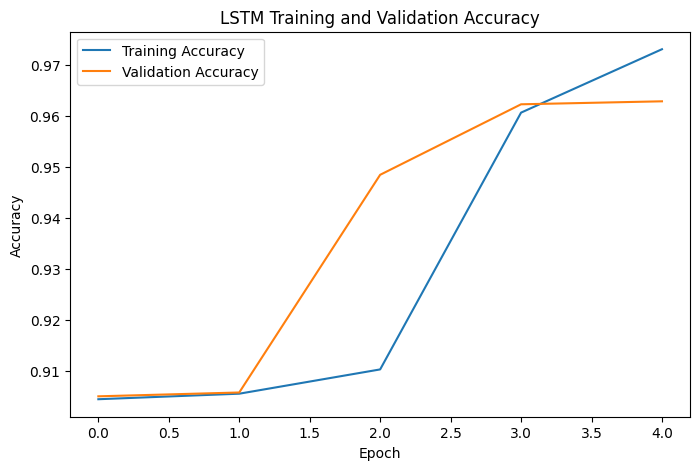

In [146]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

The accuracy curves demonstrate a clear improvement in model performance across the training epochs. Validation accuracy increased from approximately 90.50% in the first epoch to 96.28% by the fourth epoch and remained stable in the fifth epoch. Training accuracy continued to increase to 97.30%, creating only a modest gap from the final validation accuracy. This indicates that the LSTM learned effectively and achieved stable validation performance, with limited additional benefit from further training.

**11.8 LSTM Validation Predictions**

In [115]:
lstm_val_prob = lstm_model.predict(
    X_val_pad
).ravel()

lstm_val_pred = (
    lstm_val_prob >= 0.5
).astype(int)

748/748 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step


In [116]:
lstm_precision = precision_score(
    y_val,
    lstm_val_pred,
    zero_division=0
)

lstm_recall = recall_score(
    y_val,
    lstm_val_pred,
    zero_division=0
)

lstm_f1 = f1_score(
    y_val,
    lstm_val_pred,
    zero_division=0
)

lstm_auc = roc_auc_score(
    y_val,
    lstm_val_prob
)

The LSTM achieved strong performance on the validation set, with a precision of 0.847, recall of 0.740, F1-score of 0.790, and ROC-AUC of 0.972. The high precision indicates that the majority of comments predicted as positive were correctly classified. The recall of approximately 74% shows that the model identified a substantial proportion of the actual positive comments. The F1-score of 0.790 demonstrates a good balance between precision and recall, while the ROC-AUC of 0.972 indicates strong discrimination between the two classes.

**SVM Evaluation**

In [131]:
svm_val_score = svm_model.decision_function(
    X_val_tfidf
)

svm_auc = roc_auc_score(
    y_val,
    svm_val_score
)

svm_results = {
    "Model": "Linear SVM",
    "Precision": precision_score(
        y_val,
        svm_val_pred
    ),
    "Recall": recall_score(
        y_val,
        svm_val_pred
    ),
    "F1": f1_score(
        y_val,
        svm_val_pred
    ),
    "ROC-AUC": svm_auc
}

svm_results

{'Model': 'Linear SVM',
 'Precision': 0.7198292588280947,
 'Recall': 0.8086312118570184,
 'F1': 0.7616505850954629,
 'ROC-AUC': np.float64(0.9650744395181735)}

The Linear SVM achieved 95% validation accuracy, with an F1-score of 0.76 for the toxic class. Its recall of 0.83 shows that it detected most toxic comments, although the precision of 0.70 indicates some false-positive predictions. Overall, SVM provided a strong balance between detecting toxic content and maintaining classification performance.

**12.Model Comparison**

In [163]:
lstm_results = {
    "Model": "LSTM",
    "Precision": lstm_precision,
    "Recall": lstm_recall,
    "F1": lstm_f1,
    "ROC-AUC": lstm_auc
}

results = pd.DataFrame([
    {
        "Model": "Baseline",
        "Precision": precision_score(y_val, baseline_pred, zero_division=0),
        "Recall": recall_score(y_val, baseline_pred, zero_division=0),
        "F1": f1_score(y_val, baseline_pred, zero_division=0),
        "ROC-AUC": np.nan
    },
    lstm_results,
    lr_results,
    svm_results
])

results

,Model,Precision,Recall,F1,ROC-AUC
0,Baseline,0.000000,0.000000,0.000000,NaN
1,LSTM,0.846806,0.739756,0.789670,0.972170
2,Logistic Regression,0.636334,0.859634,0.731318,0.970637
3,Linear SVM,0.719829,0.808631,0.761651,0.965074



The validation results show a clear difference in how the three models handle the toxic class. Logistic Regression achieves the highest recall (0.860), meaning it identifies more toxic comments, but its lower precision (0.636) results in an F1-score of 0.731. Linear SVM improves this balance, reaching 0.720 precision, 0.809 recall and 0.762 F1-score. LSTM provides the strongest overall balance, with 0.847 precision and an F1-score of 0.790, although its recall (0.740) is lower than the two TF-IDF-based models.

Therefore, the comparison suggests a trade-off: Logistic Regression prioritises detecting toxic comments, Linear SVM provides a stronger balance, while LSTM produces fewer false toxic predictions and achieves the highest validation F1-score.



**Visualize F1:**

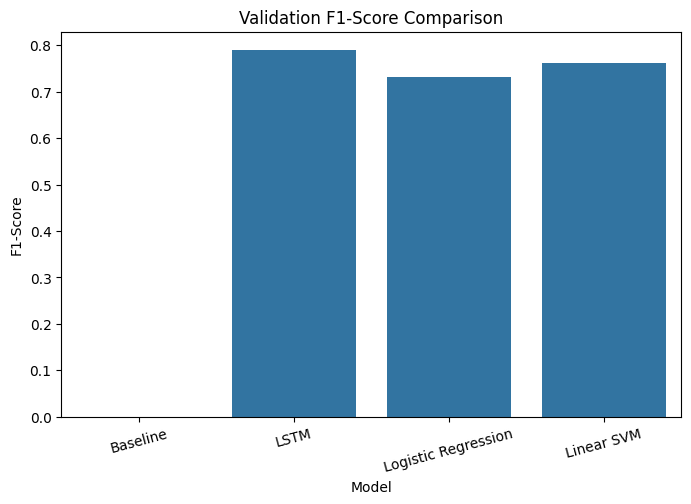

In [164]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="F1"
)

plt.title("Validation F1-Score Comparison")
plt.ylabel("F1-Score")
plt.xlabel("Model")

plt.xticks(rotation=15)

plt.show()

The candidate models were compared using validation performance, with F1-score used as the primary selection metric because it balances precision and recall. Among the evaluated models, the LSTM achieved the highest validation F1-score of 0.7897, compared with 0.7617 for Linear SVM and 0.7313 for Logistic Regression. Therefore, the LSTM was selected as the final model for evaluation on the unseen test set. The test set was not used during model selection.

**13.Hyperparameter Tuning**

In [161]:
from sklearn.model_selection import GridSearchCV

svm_params = {
    "C": [0.1, 0.5, 1, 2, 5]
}

svm_grid = GridSearchCV(
    LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    svm_params,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

svm_grid.fit(
    X_train_tfidf,
    y_train
)

GridSearchCV(cv=3,
             estimator=LinearSVC(class_weight='balanced', random_state=42),
             n_jobs=-1, param_grid={'C': [0.1, 0.5, 1, 2, 5]}, scoring='f1')

Hyperparameter tuning was applied to the Linear SVM using GridSearchCV, with F1-score as the optimisation metric. Five values of the regularisation parameter C were evaluated: 0.1, 0.5, 1, 2 and 5. The best configuration was C = 0.5, producing a cross-validation F1-score of approximately 0.753.

The result indicates that the intermediate regularisation setting provided the strongest cross-validation performance among the tested configurations. The tuned SVM therefore provides a more reliable benchmark than the initial SVM configuration before final model evaluation.

In [165]:
print("Best parameters:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

Best parameters: {'C': 0.5}
Best CV F1: 0.752609737157956


In [166]:
best_svm = svm_grid.best_estimator_

val_pred = best_svm.predict(X_val_tfidf)

print(
    classification_report(
        y_val,
        val_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     21642
           1       0.70      0.83      0.76      2294

    accuracy                           0.95     23936
   macro avg       0.84      0.90      0.87     23936
weighted avg       0.95      0.95      0.95     23936



**14.Model Selection**

F1-score was used as the primary model-selection metric because it balances precision and recall for the toxic class. Based on the validation results, LSTM achieved the highest F1-score (0.7897), followed by Linear SVM (0.7617) and Logistic Regression (0.7313). Therefore, LSTM was selected as the final model for evaluation on the unseen test set.

**15.Final Test Evaluation**

In [150]:
final_model = lstm_model

final_test_prob = final_model.predict(
    X_test_pad
).ravel()

final_test_pred = (
    final_test_prob >= 0.5
).astype(int)

748/748 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step


**Test metrics**

In [151]:
final_test_precision = precision_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_test_recall = recall_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_test_f1 = f1_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_test_auc = roc_auc_score(
    y_test,
    final_test_prob
)

print("Test Precision:", final_test_precision)
print("Test Recall:", final_test_recall)
print("Test F1:", final_test_f1)
print("Test ROC-AUC:", final_test_auc)

Test Precision: 0.8477937530986613
Test Recall: 0.7454228421970357
Test F1: 0.7933194154488518
Test ROC-AUC: 0.9723654105199397


In [152]:
print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=[
            "Non-Toxic",
            "Toxic"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Toxic       0.97      0.99      0.98     21642
       Toxic       0.85      0.75      0.79      2294

    accuracy                           0.96     23936
   macro avg       0.91      0.87      0.89     23936
weighted avg       0.96      0.96      0.96     23936






The selected LSTM achieved a test F1-score of 0.793 and ROC-AUC of 0.972, indicating strong discrimination between toxic and non-toxic comments. Its precision was 0.848, meaning that predictions labelled as toxic were generally reliable, while recall was 0.745, showing that the model identified approximately three-quarters of the toxic comments.

The class-level results also reveal an important imbalance: the model achieved an F1-score of 0.98 for non-toxic comments, compared with 0.79 for toxic comments. This difference should be considered when interpreting the overall 96% accuracy, as the majority non-toxic class contributes substantially to that figure.

**Confusion matrix**

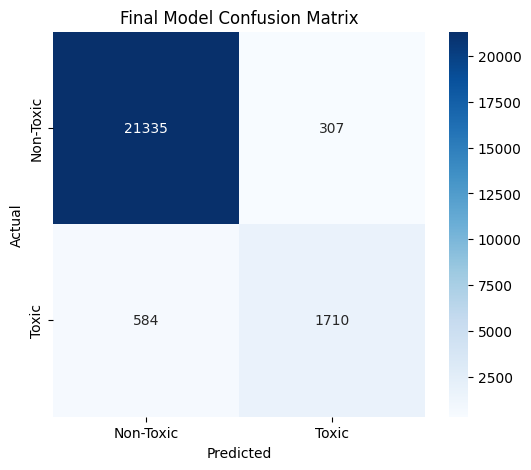

In [153]:
cm = confusion_matrix(
    y_test,
    final_test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The confusion matrix provides further insight into the test performance. The model correctly classified 21,335 non-toxic comments and 1,710 toxic comments. It incorrectly classified 307 non-toxic comments as toxic and missed 584 toxic comments.

The larger number of false negatives than false positives shows that the main remaining weakness is missing some toxic comments rather than excessively flagging non-toxic comments. This is particularly relevant for a moderation system, where undetected toxic content may require greater attention than occasional false alarms.

**16.Error Analysis**

In [154]:
error_analysis = pd.DataFrame({
    "comment": X_test,
    "actual": y_test,
    "predicted": final_test_pred
})

false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 307
False negatives: 584


In [155]:
false_positives.head(10)

,comment,actual,predicted
10779,so stop reverting the damn deletion,0,1
115445,bbb is an information nazi,0,1
61903,"not all your reason's are valid, and you are e...",0,1
154650,""" the 2012 movie was partially based on graham...",0,1
145137,""" since you ask, yes, i have gone through brit...",0,1
93410,live free or die trying!,0,1
116799,""" the lgbt barnstar awarded because your sir/m...",0,1
50088,so far the only argument you've been able to g...,0,1
105175,""": so, in effect, you are saying that i must t...",0,1
125037,harry the dirty dog u are basically on a defam...,0,1


In [156]:
false_negatives.head(10)

,comment,actual,predicted
142915,"you suck hello j. delanoy, u suck. i could tot...",1,0
85963,"""==are you serious?== you seriously have to be...",1,0
74674,2. a review of his contributions shows that co...,1,0
111464,"ok, so they weren't terrorists prior to 2001, ...",1,0
57755,"yes, and this page is wayyyyy too long as well...",1,0
133886,""" what random comments! argumentum ad hominem ...",1,0
106146,""" sukecchi: you are out of your league, and i'...",1,0
106565,""" nolan gerard funk... this article is horribl...",1,0
132481,edit filter disturbs i can't add a gay userbox...,1,0
119030,harrias is a douc hebag.,1,0


Error Analysis Summary


The error analysis focuses on the two types of misclassification: false positives and false negatives. The test results show 584 false negatives, compared with 307 false positives, indicating that the model's principal error is failing to identify some genuinely toxic comments.

These errors are likely to be particularly relevant for comments where toxicity depends on wording, context or implied meaning. This highlights that strong overall performance does not mean that every toxic comment can be reliably identified.

**17.Business Interpretation**

From a business perspective, the model could be used as a content-moderation support tool to automatically screen large volumes of online comments and prioritise potentially toxic content for human review.

The relatively high precision for the toxic class reduces unnecessary moderation alerts, while the recall of approximately 0.75 indicates that a proportion of toxic comments would still require additional detection mechanisms or human review. Therefore, the most appropriate application would be human-in-the-loop moderation rather than fully automated removal.


**18.Limitations**

- The dataset may not represent all types of online communities or languages.
- Toxicity can depend heavily on context, sarcasm and cultural interpretation.
- Class imbalance can affect model performance.
- The model may incorrectly classify ambiguous comments.
- Performance on the Jigsaw dataset does not guarantee the same performance on unseen platforms.
- Further external validation would be required before real-world deployment.


**19.Conclusion**

This analysis compared Logistic Regression, Linear SVM and LSTM for binary toxic-comment classification. The results demonstrate that the models make different trade-offs between precision and recall, with LSTM achieving the strongest validation F1-score and maintaining strong performance on the unseen test set.

The final results show that automated toxicity detection is feasible, but the remaining false negatives demonstrate that model predictions should not be treated as definitive judgments of user-generated content. A practical deployment would therefore combine automated classification with human moderation and further validation on real-world data.